# Unidad 3 · Cuatro políticas de tope de carbono con el MISMO presupuesto

**Planta:** Conservas del Itata S.A.
**Datos:** `DatosClases/3_Planificacion/Planificiacion/` — la MISMA instancia de los cuadernos 02 y 03
**Solver:** Gurobi

---

## Qué se decide aquí

Una autoridad ambiental le asigna a la planta un presupuesto de emisiones
para el trimestre. **El presupuesto es un número; la política es otra cosa.**
El mismo total se puede escribir de al menos cuatro formas:

| política | restricción | qué permite |
|---|---|---|
| **global** | $\sum_t e_t \le E$ | compensar libremente entre semanas |
| **acumulada** | $\sum_{u \le t} e_u \le E\,t/T$ | adelantar esfuerzo, nunca atrasarlo |
| **rodante** | $\sum_{u=t}^{t+w-1} e_u \le E\,w/T$ | limita las rachas, ventana de $w = 4$ |
| **por período** | $e_t \le E/T$ | nada: cada semana se rinde sola |

Las cuatro reparten **exactamente los mismos 400 513 kg CO₂e**. No hay una
más generosa que otra. Lo único que cambia es *cuándo* se autoriza emitir.

La pregunta del cuaderno: **¿cuánto cuesta esa diferencia de redacción, y qué
se compra con ella?**

## Las políticas están anidadas

Esto no es un resultado empírico: es una propiedad del conjunto factible, y
hay que verla antes de correr nada.

* Si se cumple **por período**, entonces $\sum_{u\le t} e_u \le t\,E/T$: se
  cumple **acumulado**.
* Si se cumple **acumulado** en $t = T$, se cumple **global**.
* Si se cumple **por período**, cada ventana de 4 semanas suma a lo más
  $4E/T$: se cumple **rodante**.
* Si se cumple **rodante**, las tres ventanas disjuntas 1-4, 5-8 y 9-12 suman
  a lo más $3 \cdot 4E/12 = E$: se cumple **global**.

Es decir:

$$\text{período} \Rightarrow \text{acumulado} \Rightarrow \text{global},
\qquad \text{período} \Rightarrow \text{rodante} \Rightarrow \text{global}$$

Los conjuntos factibles se encajan uno dentro de otro en ese orden, y como
minimizar sobre un conjunto más chico nunca puede dar menos:

$$\text{costo(global)} \;\le\; \text{costo(acumulado)} \;\le\; \text{costo(período)}$$
$$\text{costo(global)} \;\le\; \text{costo(rodante)} \;\le\; \text{costo(período)}$$

**Acumulado y rodante no son comparables entre sí.** Ninguna de las dos
implica la otra. Si una tabla de resultados viola alguna de las desigualdades
que sí valen, hay un error en el código: no es un hallazgo.

## Cifras de referencia

Presupuesto idéntico de **400 513 kg CO₂e**, todas resueltas con backlog y
horas extra, todas `OPTIMAL` y verificadas:

| política | costo (CLP) | preparaciones | CO₂e total | peak semanal |
|---|---|---|---|---|
| ninguna | 15 772 683 | 32 | 411 489 | 44 894 |
| global | **16 941 827** | 26 | 400 499 | 42 648 |
| rodante (4 sem.) | 25 484 046 | 26 | 400 509 | 45 039 |
| acumulada | 30 224 697 | 26 | 400 389 | 36 034 |
| por período | **30 896 718** | 26 | 400 512 | **33 376** |

Exigir el tope semana a semana cuesta **1,82 veces** lo que cuesta exigirlo
sobre el horizonte completo, con el mismo presupuesto. Y esa diferencia **no
compra ni un kilo menos de CO₂**: las cuatro emiten ≈ 400 500. Lo único que
se compra es el **peak semanal**: 44 894 → 33 376.

> **Advertencia metodológica.** Si una política recibe aunque sea un 10 % de
> holgura extra en su presupuesto, el orden se invierte y la clase concluye
> exactamente lo contrario de lo que es cierto. La sección 6 lo demuestra.
> El presupuesto tiene que ser idéntico, hasta el kilo.

**Tiempo de cómputo.** La política por período es la más dura y puede tardar
un par de minutos. Se usa `TimeLimit = 300 s` por política; el estado y el
gap se reportan para cada una.

In [1]:
import sys
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

dem = pd.read_csv(datos("3_Planificacion", "itata_demanda_plan.csv"))
par = pd.read_csv(datos("3_Planificacion", "itata_parametros_sku.csv"))
cap = pd.read_csv(datos("3_Planificacion", "itata_capacidad.csv"))
tas = pd.read_csv(datos("3_Planificacion", "itata_tasas.csv"))
ini = pd.read_csv(datos("3_Planificacion", "itata_inventario_inicial.csv"))

SKUS = list(par.sku)
T = sorted(dem.t.unique().tolist())
REC = sorted(cap.recurso.unique().tolist())
p = par.set_index("sku")

demanda = {(r.sku, int(r.t)): float(r.demanda_cajas) for _, r in dem.iterrows()}
costo_setup = {i: float(p.loc[i, "costo_setup_clp"]) for i in SKUS}
costo_almacen = {i: float(p.loc[i, "costo_almacen_clp_caja_sem"]) for i in SKUS}
costo_backlog = {i: float(p.loc[i, "costo_backlog_clp_caja_sem"]) for i in SKUS}
stock_seg = {i: float(p.loc[i, "stock_seguridad_cajas"]) for i in SKUS}
inv_final_min = dict(stock_seg)

_ini = dict(zip(ini["item"], ini.inventario_inicial.astype(float)))   # df["item"], no df.item
inv_ini = {i: _ini.get(i, 0.0) for i in SKUS}

linea = dict(zip(tas.sku, tas.linea))
consumo = {}
for _, r in tas.iterrows():
    consumo[(r.sku, "PREP")] = float(r.h_por_caja_PREP)
    consumo[(r.sku, "AUT")] = float(r.h_por_caja_AUT)
    consumo[(r.sku, r.linea)] = float(r.h_por_caja_linea)
tiempo_setup = {(r.sku, linea[r.sku]): float(r.tiempo_setup_h) for _, r in par.iterrows()}

capacidad = {(r.recurso, int(r.t)): float(r.horas_disponibles) for _, r in cap.iterrows()}
extra_max = {(r.recurso, int(r.t)): float(r.horas_extra_max) for _, r in cap.iterrows()}
costo_extra = {(r.recurso, int(r.t)): float(r.costo_hora_extra_clp) for _, r in cap.iterrows()}

# --- huella de carbono
emision_caja = {i: float(p.loc[i, "emision_kgco2_caja"]) for i in SKUS}
EMISION_SETUP = 1850.0      # kg CO2e por arranque de lote (purga y CIP)
EMISION_HORA_EXTRA = 95.0   # kg CO2e por hora extra (generacion de respaldo)

print(par[["sku", "emision_kgco2_caja"]].to_string(index=False))
print(f"\nemisión por preparación : {EMISION_SETUP:,.0f} kg CO2e")
print(f"emisión por hora extra  : {EMISION_HORA_EXTRA:,.0f} kg CO2e")

     sku  emision_kgco2_caja
 DUR-480                4.10
 DUR-820                6.05
 TOM-480                3.55
TOM-3000               12.80
 POR-480                4.60
POR-3000               14.90

emisión por preparación : 1,850 kg CO2e
emisión por hora extra  : 95 kg CO2e


## 1. De dónde sale el presupuesto (y por qué no se puede fijar a ojo)

Un error habitual es fijar el tope como "un 94 % de lo que emite el plan sin
restricción". Eso es **infactible por construcción** y no se descubre hasta
que el solver devuelve `INFEASIBLE`, momento en el cual se culpa al modelo.

La razón es que la mayor parte de las emisiones **no es una decisión**. Las
emisiones por caja son proporcionales a la demanda, y la demanda hay que
servirla: no hay pérdida de venta ni ruta alternativa. Sobre ese piso técnico
el modelo no puede hacer nada.

Lo único decidible son las **preparaciones** (1 850 kg cada una) y las
**horas extra** (95 kg cada una). Por eso el presupuesto se construye como

$$E = 1{,}02 \times \underbrace{\sum_i e_i \big(D_i - I_{i0} + \overline{I}_i\big)}_{\text{piso técnico inevitable}}
  \;+\; 1\,850 \times \underbrace{n_{\text{permitidos}}}_{\text{presupuesto de preparaciones}}$$

con `n_permitidos` fijado en poco más de la mitad de las preparaciones que
usa un plan sin restricción. Así el tope aprieta donde el modelo *puede*
reaccionar.

In [2]:
piso = sum(emision_caja[i] * max(0.0, sum(demanda[(i, t)] for t in T)
                                 - inv_ini[i] + inv_final_min[i])
           for i in SKUS)
setups_referencia = 0.45 * len(SKUS) * len(T)
setups_permitidos = max(len(SKUS), int(round(0.55 * setups_referencia)))
E = round(1.02 * piso + EMISION_SETUP * setups_permitidos, 0)

print(f"piso tecnico inevitable        : {piso:>12,.0f} kg CO2e")
print(f"margen del 2 % sobre el piso   : {1.02*piso:>12,.0f} kg CO2e")
print(f"preparaciones permitidas       : {setups_permitidos:>12d}")
print(f"presupuesto de preparaciones   : {EMISION_SETUP*setups_permitidos:>12,.0f} kg CO2e")
print(f"PRESUPUESTO TOTAL E            : {E:>12,.0f} kg CO2e")
print(f"\nEl piso es el {100*piso/E:.1f} % del presupuesto. Todo el margen de")
print("maniobra del modelo cabe en el 8 % restante, y esa es justamente la")
print("razon por la que la POLITICA importa tanto: el presupuesto es rigido.")

VENTANA = 4
tope_periodo = {t: round(E / len(T), 0) for t in T}
tope_acumulado = {t: round(E * (k + 1) / len(T), 0) for k, t in enumerate(T)}
tope_ventana = E * VENTANA / len(T)
print(f"\nreparto plano por periodo      : {tope_periodo[T[0]]:>12,.0f} kg CO2e")
print(f"cota de cada ventana de {VENTANA} sem. : {tope_ventana:>12,.0f} kg CO2e")

piso tecnico inevitable        :      360,013 kg CO2e
margen del 2 % sobre el piso   :      367,213 kg CO2e
preparaciones permitidas       :           18
presupuesto de preparaciones   :       33,300 kg CO2e
PRESUPUESTO TOTAL E            :      400,513 kg CO2e

El piso es el 89.9 % del presupuesto. Todo el margen de
maniobra del modelo cabe en el 8 % restante, y esa es justamente la
razon por la que la POLITICA importa tanto: el presupuesto es rigido.

reparto plano por periodo      :       33,376 kg CO2e
cota de cada ventana de 4 sem. :      133,504 kg CO2e


## 2. El modelo, con la política de carbono como parámetro

La base es el CLSP del cuaderno 03 con **backlog y horas extra** —las dos
válvulas que el modelo necesita para poder reaccionar al tope— y el big-M
válido con backlog, que es el del cuaderno 03.

Las emisiones del período `t` son

$$e_t = \sum_i \big( \varepsilon_i\, x_{it} + \varepsilon^{\text{setup}} y_{it} \big)
  + \sum_r \varepsilon^{\text{extra}}\, o_{rt}$$

y las cuatro políticas son cuatro formas de acotar esa misma expresión. Nótese
que el modelo **no tiene un término de carbono en el objetivo**: el carbono
es una restricción, no un precio. Esa es la diferencia entre un tope y un
impuesto, y produce comportamientos distintos.

In [3]:
def big_M(i, t, con_backlog=True):
    """La cota VALIDA con backlog (ver cuaderno 03, seccion 6)."""
    if con_backlog:
        resto = sum(demanda[(i, u)] for u in T) - inv_ini[i]
    else:
        resto = sum(demanda[(i, u)] for u in T if u >= t)
    resto = max(0.0, resto) + stock_seg[i] + inv_final_min[i]
    fisico = float("inf")
    for r in REC:
        a = consumo.get((i, r), 0.0)
        if a <= 0:
            continue
        horas = capacidad.get((r, t), 0.0) + extra_max.get((r, t), 0.0) \
            - tiempo_setup.get((i, r), 0.0)
        fisico = min(fisico, max(0.0, horas) / a)
    return float(min(resto, fisico))


def clsp_carbono(politica="ninguna", presupuesto=None, ventana=VENTANA,
                 tiempo_limite=300.0, gap=1e-4, verbose=False):
    """CLSP con backlog y horas extra, mas una de las cuatro politicas."""
    Ep = E if presupuesto is None else presupuesto
    m = gp.Model(f"CLSP-CO2-{politica}")
    m.Params.OutputFlag = 1 if verbose else 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = gap
    m.Params.Seed = 0

    x = m.addVars(SKUS, T, lb=0.0, name="x")
    y = m.addVars(SKUS, T, vtype=GRB.BINARY, name="y")
    I = m.addVars(SKUS, T, lb=0.0, name="I")
    B = m.addVars(SKUS, T, lb=0.0, name="B")
    o = m.addVars(REC, T, lb=0.0, name="o")

    for i in SKUS:
        for k, t in enumerate(T):
            prev_I = inv_ini[i] if k == 0 else I[i, T[k - 1]]
            prev_B = 0.0 if k == 0 else B[i, T[k - 1]]
            m.addConstr(prev_I - prev_B + x[i, t] - demanda[(i, t)] == I[i, t] - B[i, t],
                        name=f"bal[{i},{t}]")
        m.addConstr(B[i, T[-1]] == 0.0, name=f"sin_backlog_final[{i}]")

    for i in SKUS:
        for t in T:
            m.addConstr(x[i, t] <= big_M(i, t) * y[i, t], name=f"enl[{i},{t}]")

    for r in REC:
        for t in T:
            m.addConstr(
                gp.quicksum(consumo.get((i, r), 0.0) * x[i, t]
                            + tiempo_setup.get((i, r), 0.0) * y[i, t] for i in SKUS)
                <= capacidad[(r, t)] + o[r, t], name=f"cap[{r},{t}]")
            m.addConstr(o[r, t] <= extra_max[(r, t)], name=f"omax[{r},{t}]")

    # --- emisiones del periodo t
    def emision(t):
        return (gp.quicksum(emision_caja[i] * x[i, t] + EMISION_SETUP * y[i, t]
                            for i in SKUS)
                + gp.quicksum(EMISION_HORA_EXTRA * o[r, t] for r in REC))

    if politica == "global":
        m.addConstr(gp.quicksum(emision(t) for t in T) <= Ep, name="co2_global")
    elif politica == "periodo":
        for t in T:
            m.addConstr(emision(t) <= round(Ep / len(T), 0), name=f"co2_periodo[{t}]")
    elif politica == "acumulado":
        for k, t in enumerate(T):
            m.addConstr(gp.quicksum(emision(T[j]) for j in range(k + 1))
                        <= round(Ep * (k + 1) / len(T), 0), name=f"co2_acum[{t}]")
    elif politica == "rodante":
        w = max(1, ventana)
        for k in range(len(T) - w + 1):
            m.addConstr(gp.quicksum(emision(T[j]) for j in range(k, k + w))
                        <= Ep * w / len(T), name=f"co2_rodante[{T[k]}]")
    elif politica != "ninguna":
        raise ValueError("politica: 'ninguna', 'global', 'periodo', "
                         "'acumulado' o 'rodante'")

    c_setup = gp.quicksum(costo_setup[i] * y[i, t] for i in SKUS for t in T)
    c_alm = gp.quicksum(costo_almacen[i] * I[i, t] for i in SKUS for t in T)
    c_back = gp.quicksum(costo_backlog[i] * B[i, t] for i in SKUS for t in T)
    c_extra = gp.quicksum(costo_extra[(r, t)] * o[r, t] for r in REC for t in T)
    m.setObjective(c_setup + c_alm + c_back + c_extra, GRB.MINIMIZE)

    m.optimize()
    return m, {"x": x, "y": y, "I": I, "B": B, "o": o}


ESTADO = {GRB.OPTIMAL: "OPTIMAL", GRB.TIME_LIMIT: "TIME_LIMIT",
          GRB.INFEASIBLE: "INFEASIBLE", GRB.INF_OR_UNBD: "INF_OR_UNBD"}


def perfil_emisiones(v):
    """Emisiones de cada periodo, recalculadas desde la SOLUCION."""
    return {t: sum(emision_caja[i] * v["x"][i, t].X
                   + EMISION_SETUP * round(v["y"][i, t].X) for i in SKUS)
            + sum(EMISION_HORA_EXTRA * v["o"][r, t].X for r in REC)
            for t in T}

## 3. Las cuatro políticas, con el mismo presupuesto

Cada corrida tiene `TimeLimit = 300 s`. Se reporta estado, gap, tamaño del
modelo y tiempo, porque una tabla de costos sin esas columnas no es
comparable: un 30 % más caro puede ser una política más dura o un solver que
se quedó a medio camino, y no hay forma de distinguirlo sin el gap.

In [4]:
POLITICAS = ["ninguna", "global", "rodante", "acumulado", "periodo"]
resultados, perfiles = [], {}

for pol in POLITICAS:
    t0 = time.perf_counter()
    m_, v_ = clsp_carbono(politica=pol, tiempo_limite=300.0)
    seg = time.perf_counter() - t0
    if m_.SolCount == 0:
        print(f"{pol:10s} {ESTADO.get(m_.Status, m_.Status)} — sin solución")
        continue
    e_t = perfil_emisiones(v_)
    perfiles[pol] = e_t
    setups = int(round(sum(v_["y"][i, t].X for i in SKUS for t in T)))
    resultados.append({
        "politica": pol, "estado": ESTADO.get(m_.Status, str(m_.Status)),
        "objetivo": m_.ObjVal, "gap_%": 100 * m_.MIPGap, "setups": setups,
        "CO2e_total": sum(e_t.values()), "peak_semanal": max(e_t.values()),
        "horas_extra_h": sum(v_["o"][r, t].X for r in REC for t in T),
        "backlog_cajas": sum(v_["B"][i, t].X for i in SKUS for t in T),
        "variables": m_.NumVars, "binarias": m_.NumBinVars,
        "restricciones": m_.NumConstrs, "segundos": seg})
    print(f"{pol:10s} {ESTADO.get(m_.Status, m_.Status):8s} "
          f"obj {m_.ObjVal:>12,.0f} | gap {100*m_.MIPGap:5.2f} % | "
          f"{setups:2d} setups | CO2e {sum(e_t.values()):>9,.0f} | "
          f"peak {max(e_t.values()):>7,.0f} | {m_.NumVars} var "
          f"({m_.NumBinVars} bin), {m_.NumConstrs} restr | {seg:5.0f} s")

res = pd.DataFrame(resultados).set_index("politica")
print()
print(res[["objetivo", "setups", "CO2e_total", "peak_semanal",
           "horas_extra_h", "backlog_cajas"]].to_string(
    float_format=lambda v: f"{v:,.0f}"))

Restricted license - for non-production use only - expires 2027-11-29


ninguna    OPTIMAL  obj   15,772,683 | gap  0.00 % | 32 setups | CO2e   411,489 | peak  44,894 | 336 var (72 bin), 246 restr |     2 s


global     OPTIMAL  obj   16,941,827 | gap  0.00 % | 26 setups | CO2e   400,499 | peak  42,648 | 336 var (72 bin), 247 restr |     3 s


rodante    OPTIMAL  obj   25,484,046 | gap  0.00 % | 26 setups | CO2e   400,509 | peak  45,039 | 336 var (72 bin), 255 restr |     4 s


acumulado  OPTIMAL  obj   30,224,697 | gap  0.00 % | 26 setups | CO2e   400,389 | peak  36,034 | 336 var (72 bin), 258 restr |     7 s


periodo    OPTIMAL  obj   30,896,718 | gap  0.00 % | 26 setups | CO2e   400,512 | peak  33,376 | 336 var (72 bin), 258 restr |    20 s

            objetivo  setups  CO2e_total  peak_semanal  horas_extra_h  backlog_cajas
politica                                                                            
ninguna   15,772,683      32     411,489        44,894              0            192
global    16,941,827      26     400,499        42,648              1          3,426
rodante   25,484,046      26     400,509        45,039              1         18,651
acumulado 30,224,697      26     400,389        36,034              0         23,628
periodo   30,896,718      26     400,512        33,376              1         24,627


## 4. El gráfico del cuaderno

Este es el punto. Las cuatro políticas emiten prácticamente lo mismo; lo que
cambia es la **forma** del perfil semanal. La línea del reparto plano
(E / T = 33 376 kg) es la referencia: la política por período obliga a que
ninguna barra la pase; la global deja que la pase cuanto quiera mientras el
área total cuadre.

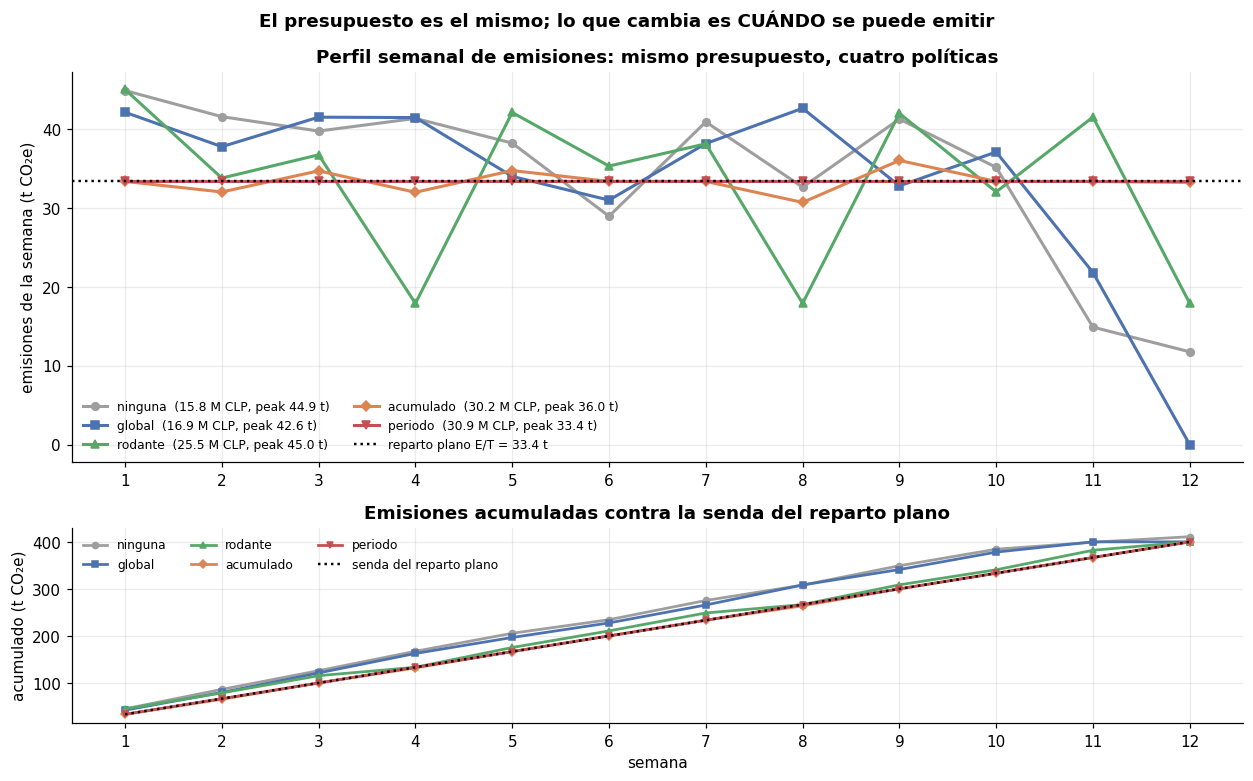

           costo_M_CLP  CO2e_total_t  peak_t  sobrecosto_vs_global_%
politica                                                            
ninguna          15.77        411.49   44.89                   -6.90
global           16.94        400.50   42.65                    0.00
rodante          25.48        400.51   45.04                   50.42
acumulado        30.22        400.39   36.03                   78.40
periodo          30.90        400.51   33.38                   82.37


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11.5, 7.2),
                               gridspec_kw={"height_ratios": [2, 1]})

colores = {"ninguna": "#9e9e9e", "global": "#4c72b0", "rodante": "#55a868",
           "acumulado": "#dd8452", "periodo": "#c44e52"}
marcas = {"ninguna": "o", "global": "s", "rodante": "^", "acumulado": "D",
          "periodo": "v"}
for pol in POLITICAS:
    if pol not in perfiles:
        continue
    ax1.plot(T, [perfiles[pol][t] / 1000 for t in T], marker=marcas[pol],
             color=colores[pol], lw=2.0, ms=5,
             label=f"{pol}  ({res.loc[pol,'objetivo']/1e6:,.1f} M CLP, "
                   f"peak {res.loc[pol,'peak_semanal']/1000:,.1f} t)")
ax1.axhline(E / len(T) / 1000, color="black", ls=":", lw=1.6,
            label=f"reparto plano E/T = {E/len(T)/1000:,.1f} t")
ax1.set_ylabel("emisiones de la semana (t CO₂e)")
ax1.set_xticks(T)
ax1.set_title("Perfil semanal de emisiones: mismo presupuesto, cuatro políticas")
ax1.legend(fontsize=8, ncol=2)

# emisiones acumuladas: aqui se ve por que 'acumulado' aprieta tanto
for pol in POLITICAS:
    if pol not in perfiles:
        continue
    ax2.plot(T, np.cumsum([perfiles[pol][t] for t in T]) / 1000,
             marker=marcas[pol], color=colores[pol], lw=1.8, ms=4, label=pol)
ax2.plot(T, [E * (k + 1) / len(T) / 1000 for k in range(len(T))],
         color="black", ls=":", lw=1.6, label="senda del reparto plano")
ax2.set_ylabel("acumulado (t CO₂e)")
ax2.set_xlabel("semana")
ax2.set_xticks(T)
ax2.set_title("Emisiones acumuladas contra la senda del reparto plano")
ax2.legend(fontsize=8, ncol=3)
fig.suptitle("El presupuesto es el mismo; lo que cambia es CUÁNDO se puede emitir",
             fontweight="bold")
figura(fig, "carbono_perfiles")
plt.show()

comparacion = pd.DataFrame({
    "costo_M_CLP": res.objetivo / 1e6,
    "CO2e_total_t": res.CO2e_total / 1000,
    "peak_t": res.peak_semanal / 1000,
    "sobrecosto_vs_global_%": 100 * (res.objetivo - res.loc["global", "objetivo"])
    / res.loc["global", "objetivo"],
})
print(comparacion.to_string(float_format=lambda v: f"{v:,.2f}"))

### La lectura

**Las emisiones totales son las mismas en las cuatro.** 400 499, 400 509,
400 389 y 400 512 kg. Diferencias de tres dígitos sobre cuatrocientas mil:
ruido de redondeo. La restricción está activa en las cuatro y el modelo la
agota en las cuatro.

**Los costos van de 16,9 a 30,9 millones.** La política por período cuesta
**1,82 veces** lo que cuesta la global. Trece millones de pesos de diferencia
por una diferencia de redacción de la norma.

**Lo que se compra con esos trece millones es el peak, no el total.** El peak
semanal baja de 44 894 a 33 376 kg. Si lo que importa es la calidad del aire
local en la semana peor —que es una preocupación perfectamente razonable— la
política por período hace exactamente lo que promete. Si lo que importa es el
total anual —que es lo que importa para el clima— entonces esos trece
millones no compran nada.

**La rodante es el caso interesante.** Tiene el peak más alto de todas
(45 039 kg, incluso por encima del plan sin restricción) y aun así cuesta
25,5 millones. No controla el peak: controla la **racha**. Permite una semana
muy alta siempre que las tres vecinas compensen, lo que es una política
razonable para un contaminante que se acumula en el aire y se disipa en
semanas.

**La lección de gestión.** Antes de discutir *cuánto* se puede emitir hay que
decidir *qué* se quiere controlar: el stock (total acumulado), el flujo
instantáneo (peak) o la racha (ventana). Son tres objetivos ambientales
distintos y ninguna cifra de presupuesto los distingue. La política sí.

## 5. Verificación del orden teórico

La sección inicial demostró que los conjuntos factibles están anidados. Eso
obliga a un orden en los costos. Comprobarlo no es una formalidad: es el
control de calidad que detecta un presupuesto mal repartido o una restricción
mal escrita.

In [6]:
c = res.objetivo
print("Cadenas que DEBEN cumplirse:\n")
pares = [("ninguna", "global"), ("global", "acumulado"), ("acumulado", "periodo"),
         ("global", "rodante"), ("rodante", "periodo")]
todo_ok = True
for a, b in pares:
    ok = c[a] <= c[b] + 1e-6
    todo_ok &= ok
    print(f"  costo({a}) <= costo({b})  :  {c[a]:>12,.0f} <= {c[b]:>12,.0f}  "
          f"{'OK' if ok else 'FALLA'}")
print("\nY una que NO tiene por que cumplirse en ningun sentido, porque")
print("'acumulado' y 'rodante' no se implican mutuamente:")
print(f"  costo(rodante) vs costo(acumulado): {c['rodante']:,.0f} vs "
      f"{c['acumulado']:,.0f}")
print("  En esta instancia gana la rodante; en otra podria ser al reves, y")
print("  ninguna de las dos cosas seria un error.")

Cadenas que DEBEN cumplirse:

  costo(ninguna) <= costo(global)  :    15,772,683 <=   16,941,827  OK
  costo(global) <= costo(acumulado)  :    16,941,827 <=   30,224,697  OK
  costo(acumulado) <= costo(periodo)  :    30,224,697 <=   30,896,718  OK
  costo(global) <= costo(rodante)  :    16,941,827 <=   25,484,046  OK
  costo(rodante) <= costo(periodo)  :    25,484,046 <=   30,896,718  OK

Y una que NO tiene por que cumplirse en ningun sentido, porque
'acumulado' y 'rodante' no se implican mutuamente:
  costo(rodante) vs costo(acumulado): 25,484,046 vs 30,224,697
  En esta instancia gana la rodante; en otra podria ser al reves, y
  ninguna de las dos cosas seria un error.


## 6. La advertencia: un 10 % de holgura y la clase aprende lo contrario

La comparación de arriba vale **solo** porque el presupuesto es idéntico
hasta el kilo. Es fácil no darse cuenta de lo frágil que es eso. Basta con
que alguien decida "redondear para arriba" el tope por período, o que use un
`E` distinto por política porque los calculó en sesiones distintas.

Se repite la política más cara —la de período— con un presupuesto **10 % más
grande** y nada más cambiado.

In [7]:
m10, v10 = clsp_carbono(politica="periodo", presupuesto=E * 1.10,
                        tiempo_limite=300.0)
e10 = perfil_emisiones(v10)
z10 = m10.ObjVal
print(f"periodo con E + 10 %  ->  {ESTADO.get(m10.Status, m10.Status)}  "
      f"obj {z10:,.0f} CLP  |  CO2e {sum(e10.values()):,.0f} kg  "
      f"|  peak {max(e10.values()):,.0f} kg\n")

orden = pd.DataFrame({
    "politica": ["global (E)", "período (E + 10 %)", "rodante (E)",
                 "acumulado (E)", "período (E)"],
    "costo": [c["global"], z10, c["rodante"], c["acumulado"], c["periodo"]],
    "presupuesto": [E, E * 1.10, E, E, E]}).sort_values("costo")
print(orden.to_string(index=False, float_format=lambda v: f"{v:,.0f}"))

print("\nCon un 10 % de holgura, la politica MAS RIGIDA pasa de ser la mas cara")
print("de las cuatro a ser la segunda mas barata, por delante de la rodante y")
print("de la acumulada. Un cuadro asi, presentado en clase, ensenia exactamente")
print("lo contrario de lo que es cierto: que apretar semana a semana 'no es tan")
print("caro'. Y no hay nada en la tabla que delate el error, salvo la columna")
print("del presupuesto.")
print("\nRegla practica: el presupuesto se calcula UNA vez, se guarda en una")
print("variable y se pasa a las cuatro corridas. Nunca se reescribe por politica.")

periodo con E + 10 %  ->  OPTIMAL  obj 20,223,067 CLP  |  CO2e 413,339 kg  |  peak 36,714 kg

          politica      costo  presupuesto
        global (E) 16,941,827      400,513
período (E + 10 %) 20,223,067      440,564
       rodante (E) 25,484,046      400,513
     acumulado (E) 30,224,697      400,513
       período (E) 30,896,718      400,513

Con un 10 % de holgura, la politica MAS RIGIDA pasa de ser la mas cara
de las cuatro a ser la segunda mas barata, por delante de la rodante y
de la acumulada. Un cuadro asi, presentado en clase, ensenia exactamente
lo contrario de lo que es cierto: que apretar semana a semana 'no es tan
caro'. Y no hay nada en la tabla que delate el error, salvo la columna
del presupuesto.

Regla practica: el presupuesto se calcula UNA vez, se guarda en una
variable y se pasa a las cuatro corridas. Nunca se reescribe por politica.


## 7. Comprobación

In [8]:
print("Comprobación:")
ok = []
ok.append(verificar(E, 400_513.0, "presupuesto de carbono (kg CO2e)", tol=1e-6))
ok.append(verificar(c["ninguna"], 15_772_683.0, "sin política (CLP)", tol=1e-5))
ok.append(verificar(c["global"], 16_941_827.0, "política global (CLP)", tol=1e-5))
ok.append(verificar(c["rodante"], 25_484_046.0, "política rodante (CLP)", tol=1e-5))
ok.append(verificar(c["acumulado"], 30_224_697.0, "política acumulada (CLP)", tol=1e-5))
ok.append(verificar(c["periodo"], 30_896_718.0, "política por período (CLP)", tol=1e-5))
ok.append(verificar(float(res.loc["periodo", "peak_semanal"]), 33_376.0,
                    "peak semanal, por período (kg)", tol=1e-3))
ok.append(verificar(float(res.loc["ninguna", "peak_semanal"]), 44_894.0,
                    "peak semanal, sin política (kg)", tol=1e-3))
ok.append(verificar(c["periodo"] / c["global"], 1.82,
                    "razón costo(período) / costo(global)", tol=5e-3))
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")

assert todo_ok, "el orden teorico de las politicas anidadas no se cumple"
assert (res.estado == "OPTIMAL").all(), "alguna politica no cerro a optimalidad"
# el presupuesto se agota en las cuatro: la diferencia de costo NO compra CO2
con_tope = res.drop(index="ninguna")
assert (abs(con_tope.CO2e_total - E) / E < 0.005).all(), \
    "toda politica activa deberia agotar el presupuesto"
assert res.loc["periodo", "peak_semanal"] < res.loc["ninguna", "peak_semanal"], \
    "la politica por periodo debe bajar el peak"
assert z10 < c["rodante"], \
    "con 10 % de holgura la politica mas rigida se ve mas barata que la rodante"

perf = pd.DataFrame({pol: pd.Series(perfiles[pol]) for pol in perfiles})
perf.index.name = "t"
tabla(perf.reset_index(), "carbono_perfil_semanal")
tabla(res.reset_index(), "carbono_politicas")
resumen({"presupuesto_kgco2e": float(E),
         "costos": {k: float(v) for k, v in c.items()},
         "peak_semanal": {k: float(v) for k, v in res.peak_semanal.items()},
         "co2e_total": {k: float(v) for k, v in res.CO2e_total.items()},
         "razon_periodo_global": float(c["periodo"] / c["global"]),
         "periodo_con_10pct_holgura": float(z10)}, "resumen_carbono")
print("Guardado en resultados/")

Comprobación:
  [  OK  ] presupuesto de carbono (kg CO2e): obtenido 400,513.0000 | referencia 400,513.0000 | dif. relativa 0.00e+00
  [  OK  ] sin política (CLP): obtenido 15,772,683.1442 | referencia 15,772,683.0000 | dif. relativa 9.14e-09
  [  OK  ] política global (CLP): obtenido 16,941,826.8441 | referencia 16,941,827.0000 | dif. relativa 9.20e-09
  [  OK  ] política rodante (CLP): obtenido 25,484,045.8533 | referencia 25,484,046.0000 | dif. relativa 5.76e-09
  [  OK  ] política acumulada (CLP): obtenido 30,224,697.1369 | referencia 30,224,697.0000 | dif. relativa 4.53e-09
  [  OK  ] política por período (CLP): obtenido 30,896,718.0748 | referencia 30,896,718.0000 | dif. relativa 2.42e-09
  [  OK  ] peak semanal, por período (kg): obtenido 33,376.0000 | referencia 33,376.0000 | dif. relativa 0.00e+00
  [  OK  ] peak semanal, sin política (kg): obtenido 44,894.2936 | referencia 44,894.0000 | dif. relativa 6.54e-06
  [  OK  ] razón costo(período) / costo(global): obtenido 1.8237 | r

---

## Para llevarse

1. **El presupuesto no define la política.** Cuatro normas con el mismo total
   producen costos entre 16,9 y 30,9 millones. La redacción de la norma es
   una decisión económica, no una formalidad legal.
2. **Las políticas están anidadas y eso obliga a un orden de costos.**
   período ⟹ acumulado ⟹ global y período ⟹ rodante ⟹ global. Si la tabla no
   respeta ese orden, hay un error en el código. Acumulado y rodante no son
   comparables entre sí.
3. **Apretar semana a semana cuesta 1,82× y no ahorra ni un kilo.** Las
   cuatro emiten ≈ 400 500 kg. Lo único que cambia es *cuándo*, y eso se ve
   en el peak: 44 894 → 33 376.
4. **Hay que decidir qué se quiere controlar antes de cuánto.** Total
   acumulado, peak instantáneo o racha son tres objetivos ambientales
   distintos, y corresponden a global, por período y rodante. Ninguna cifra
   de presupuesto los distingue.
5. **La comparación es frágil.** Un 10 % de holgura en una sola política
   invierte el orden y la conclusión. El presupuesto se calcula una vez y se
   pasa a las cuatro corridas.
6. **Un tope no es un impuesto.** Aquí el carbono es una restricción y no
   aparece en el objetivo. Con un impuesto el modelo compraría emisiones
   hasta igualar el precio marginal; con un tope simplemente no puede. Los
   planes que salen son distintos.

## Ejercicios

1. Agregue una quinta política: tope por período pero con **traspaso**
   (*banking*), es decir, lo no emitido en `t` se puede usar en `t+1` hasta un
   máximo del 50 % de la cuota. ¿Dónde queda su costo respecto de las cuatro?
   Prediga la respuesta con el argumento de anidamiento antes de resolver.
2. Reemplace el tope global por un **impuesto** de τ CLP por kg CO₂e en el
   objetivo, sin restricción. Busque el τ que produce exactamente 400 513 kg
   de emisión. ¿El plan resultante es el mismo que el de la política global?
   ¿Debería serlo?
3. Varíe el ancho de la ventana rodante (w = 2, 3, 4, 6, 12) manteniendo el
   presupuesto proporcional `E·w/T`. Grafique costo y peak contra `w`.
   Verifique que en `w = 1` coincide con "por período" y en `w = 12` con
   "global", y explique por qué debe ser así.
4. El presupuesto se construyó con `setups_permitidos = 18`. Baje ese número
   hasta que la política por período se vuelva infactible. ¿Cuántas
   preparaciones necesita la planta como mínimo? Contraste esa cifra con las
   26 que usan las cuatro políticas.
5. Las cuatro políticas dan 26 preparaciones. Compare los **planes**, no los
   totales: ¿son las mismas 26? Si no lo son, ¿en qué semanas difieren y por
   qué?